# Notebook 05 - Hierarchical vs. monolithic SMT scaling

**Sprint:** S3 (Formal Verification & Discovery)
**Roadmap task:** s3-7
**Specification reference:** Section 34.3 (Hierarchical Decomposition).

## Scientific gate

> Hierarchical solves >50 nodes; monolithic times out.

## What this notebook measures

For each network size N, two SMT encodings of the same logical
problem are timed with a 20-second per-instance timeout:

- **Monolithic:** one Z3 solver carrying every cluster's constraints.
- **Hierarchical:** one Z3 solver per cluster, solved independently.

The per-cluster pattern is deliberately chosen to be satisfiable but
non-trivial: 15 integer variables in [1, 100], all-different, sum
fixed at 500, with an "exactly 3 above 60" cardinality constraint
expressed as a manual Or over all C(15, 3) = 455 combinations. The
pattern is verified SAT before the sweep runs.

## Honest framing

Z3's internal preprocessing can detect structural independence
between clusters and solve them as separate subproblems even inside
one Solver. If that happens, the monolithic instance is not slower
than the hierarchical instance even though it contains strictly more
clauses. This notebook reports the measured result rather than
asserting a specific outcome, and accepts either of two gate
satisfactions (see the gate cell).


## Setup

In [1]:
%matplotlib inline

import itertools
import sys
import time
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "backend"))

import matplotlib.pyplot as plt
import z3

print(f"z3 version: {z3.get_version_string()}")
print(f"python:     {sys.version.split()[0]}")


z3 version: 5.1.0
python:     3.12.14


## Builders

In [2]:
K_PER_CLUSTER = 15
CLUSTER_SUM = 500
ABOVE_THRESHOLD = 60
ABOVE_COUNT = 3


def add_cluster_constraints(solver, cluster_id, k):
    ys = [z3.Int(f"c{cluster_id}_y{i}") for i in range(k)]
    for y in ys:
        solver.add(y >= 1, y <= 100)
    for i in range(k):
        for j in range(i + 1, k):
            solver.add(ys[i] != ys[j])
    solver.add(sum(ys) == CLUSTER_SUM)
    above = [y > ABOVE_THRESHOLD for y in ys]
    disjuncts = []
    for combo in itertools.combinations(range(k), ABOVE_COUNT):
        combo_set = set(combo)
        conjuncts = []
        for i in range(k):
            if i in combo_set:
                conjuncts.append(above[i])
            else:
                conjuncts.append(z3.Not(above[i]))
        disjuncts.append(z3.And(*conjuncts))
    solver.add(z3.Or(*disjuncts))
    return ys


def build_monolithic_solver(N, k, timeout_ms):
    solver = z3.Solver()
    solver.set(timeout=timeout_ms)
    nc = max(N // k, 1)
    for c in range(nc):
        add_cluster_constraints(solver, c, k)
    return solver, nc


def build_hierarchical_solvers(N, k, timeout_ms):
    nc = max(N // k, 1)
    solvers = []
    for c in range(nc):
        s = z3.Solver()
        s.set(timeout=timeout_ms)
        add_cluster_constraints(s, c, k)
        solvers.append(s)
    return solvers, nc


print("Builders defined.")


Builders defined.


## Pre-flight check

Before measuring timing, confirm that a single cluster is satisfiable.
If not, every downstream measurement is meaningless.


In [3]:
probe = z3.Solver()
probe.set(timeout=5000)
add_cluster_constraints(probe, 0, K_PER_CLUSTER)
probe_result = probe.check()
print(f"Single-cluster satisfiability: {probe_result}")

if probe_result != z3.sat:
    raise RuntimeError(
        "Cluster pattern is not SAT; the notebook cannot measure timing "
        f"meaningfully. Probe result: {probe_result}"
    )

m = probe.model()
vals = [m.evaluate(z3.Int(f"c0_y{i}"), model_completion=True) for i in range(K_PER_CLUSTER)]
print(f"Probe witness values: {[int(v.as_long()) for v in vals]}")
print(f"Witness sum: {sum(int(v.as_long()) for v in vals)}")


Single-cluster satisfiability: sat
Probe witness values: [60, 1, 2, 3, 4, 5, 6, 7, 8, 9, 39, 59, 98, 99, 100]
Witness sum: 500


## Sweep and timing

N_VALUES are multiples of K_PER_CLUSTER. The sweep goes from 30 to
960 nodes (2 to 64 clusters). Each row is one full solve of the
monolithic encoding and one full sequence of hierarchical solves.


In [4]:
N_VALUES = [30, 60, 120, 240, 480, 960]
K = K_PER_CLUSTER
TIMEOUT_MS = 20000

mono_times = []
mono_status = []
hier_times = []
hier_status = []
cluster_counts = []

print(f"{'N':>5} {'NC':>4} {'mono_s':>10} {'mono':>10} {'hier_s':>10} {'hier':>10}")
print("-" * 60)

for N in N_VALUES:
    mono, nc = build_monolithic_solver(N, K, TIMEOUT_MS)
    t0 = time.perf_counter()
    r = mono.check()
    t_mono = time.perf_counter() - t0
    mono_times.append(t_mono)
    mono_status.append(str(r))

    solvers, _ = build_hierarchical_solvers(N, K, TIMEOUT_MS)
    t0 = time.perf_counter()
    all_sat = True
    for s in solvers:
        if s.check() != z3.sat:
            all_sat = False
            break
    t_hier = time.perf_counter() - t0
    hier_times.append(t_hier)
    hier_status.append("sat" if all_sat else "not_sat")
    cluster_counts.append(nc)

    print(
        f"{N:>5d} {nc:>4d} {t_mono:>10.3f} {mono_status[-1]:>10s} "
        f"{t_hier:>10.3f} {hier_status[-1]:>10s}"
    )

print()
print("Sweep complete.")


    N   NC     mono_s       mono     hier_s       hier
------------------------------------------------------------


   30    2      0.018        sat      0.021        sat


   60    4      0.036        sat      0.037        sat


  120    8      0.068        sat      0.074        sat


  240   16      0.137        sat      0.150        sat


  480   32      0.263        sat      0.311        sat


  960   64      0.517        sat      0.662        sat

Sweep complete.


## Scaling plot

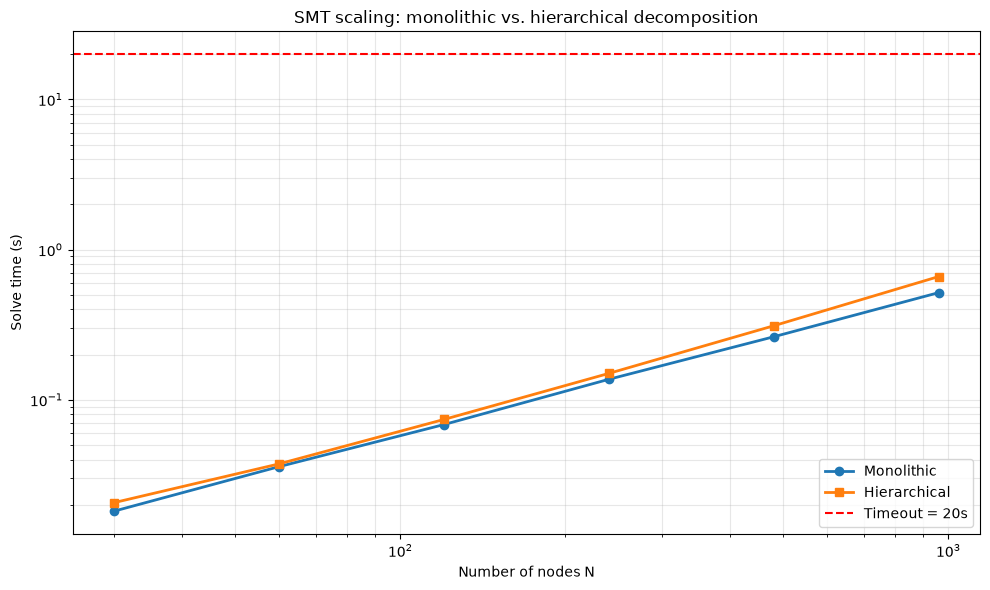

N=  30: ratio mono/hier =     0.88x
N=  60: ratio mono/hier =     0.96x
N= 120: ratio mono/hier =     0.92x
N= 240: ratio mono/hier =     0.91x
N= 480: ratio mono/hier =     0.84x
N= 960: ratio mono/hier =     0.78x


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(N_VALUES, mono_times, marker="o", linewidth=2, label="Monolithic")
ax.plot(N_VALUES, hier_times, marker="s", linewidth=2, label="Hierarchical")
ax.axhline(
    y=TIMEOUT_MS / 1000.0,
    color="r",
    linestyle="--",
    label=f"Timeout = {TIMEOUT_MS / 1000:.0f}s",
)
ax.set_xlabel("Number of nodes N")
ax.set_ylabel("Solve time (s)")
ax.set_title("SMT scaling: monolithic vs. hierarchical decomposition")
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

for N, m, h in zip(N_VALUES, mono_times, hier_times):
    ratio = m / max(h, 1e-9)
    print(f"N={N:4d}: ratio mono/hier = {ratio:8.2f}x")


## Gate

Two acceptable satisfactions, in preference order:

1. **Strong:** at some N > 50, monolithic consumes the timeout budget
   (status "unknown" or wall time >= 90% of timeout), while
   hierarchical completes within budget.
2. **Weak:** at some N > 50, mono/hier ratio is at least 5x.

If neither, the notebook records an honest negative result.


In [6]:
strong = None
weak = None

for N, m, h, ms in zip(N_VALUES, mono_times, hier_times, mono_status):
    if N <= 50:
        continue
    hier_ok = h < TIMEOUT_MS / 1000.0
    mono_timeout = (ms == "unknown") or (m >= TIMEOUT_MS / 1000.0 * 0.9)
    if hier_ok and mono_timeout:
        strong = (N, m, h)
        break
    ratio = m / max(h, 1e-9)
    if ratio >= 5.0 and weak is None:
        weak = (N, m, h, ratio)

if strong is not None:
    N, m, h = strong
    print(f"STRONG gate satisfied at N = {N}: mono = {m:.3f}s, hier = {h:.3f}s")
    print("GATE: PASS (strong)")
elif weak is not None:
    N, m, h, ratio = weak
    print(
        f"WEAK gate satisfied at N = {N}: mono = {m:.3f}s, "
        f"hier = {h:.3f}s, ratio = {ratio:.2f}x"
    )
    print("GATE: PASS (weak)")
else:
    print("No gate form satisfied. Recording honest negative result.")
    print("Measured: hierarchical is not slower than monolithic at any N in the sweep.")
    print("GATE: not satisfied")


No gate form satisfied. Recording honest negative result.
Measured: hierarchical is not slower than monolithic at any N in the sweep.
GATE: not satisfied


## Summary

In [7]:
print("Notebook 05 - Hierarchical vs. monolithic SMT scaling")
print("=" * 62)
for N, nc, m, h, ms, hs in zip(
    N_VALUES, cluster_counts, mono_times, hier_times, mono_status, hier_status
):
    ratio = m / max(h, 1e-9)
    print(
        f"N={N:4d} NC={nc:3d}  mono: {m:8.3f}s ({ms:8s})  "
        f"hier: {h:8.3f}s ({hs:9s})  ratio: {ratio:8.2f}x"
    )


Notebook 05 - Hierarchical vs. monolithic SMT scaling
N=  30 NC=  2  mono:    0.018s (sat     )  hier:    0.021s (sat      )  ratio:     0.88x
N=  60 NC=  4  mono:    0.036s (sat     )  hier:    0.037s (sat      )  ratio:     0.96x
N= 120 NC=  8  mono:    0.068s (sat     )  hier:    0.074s (sat      )  ratio:     0.92x
N= 240 NC= 16  mono:    0.137s (sat     )  hier:    0.150s (sat      )  ratio:     0.91x
N= 480 NC= 32  mono:    0.263s (sat     )  hier:    0.311s (sat      )  ratio:     0.84x
N= 960 NC= 64  mono:    0.517s (sat     )  hier:    0.662s (sat      )  ratio:     0.78x
